# Avance 2 — Ingeniería de Características

**Proyecto:** Trading Agent Ecosystem — Clasificación de Dirección de Mercado (LONG / SHORT)  
**Dataset:** 56 161 muestras etiquetadas | 18 meses | 12 símbolos | Timeframes: 15m, 1h, 4h  
**Metodología:** CRISP-ML(Q)  

---

## Contexto del problema

Dado un conjunto de indicadores técnicos multi-timeframe calculados sobre velas de criptomonedas (Binance), el modelo debe predecir si el movimiento de precio neto en las próximas 24 velas será alcista (**LONG**) o bajista (**SHORT**). Las etiquetas fueron generadas con *hindsight labeling* con filtros de calidad (vol_ratio ≥ 0.5, ADX ≥ 15, R:R ≥ 1.0).

Esta fase corresponde a **Data Preparation** dentro de CRISP-ML(Q), enfocándose en la ingeniería de características para optimizar el rendimiento de los modelos (XGBoost, Random Forest y LSTM).

## 0. Configuración e Importaciones

In [27]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, f_classif, chi2, SelectKBest
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PowerTransformer, OneHotEncoder
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
RANDOM_STATE = 42

# ── Ruta al dataset ──────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
DATASET_PATH = NOTEBOOK_DIR / 'backtest' / 'data' / 'labeled' / 'dataset.jsonl'
if not DATASET_PATH.exists():
    # Fallback: ruta absoluta
    DATASET_PATH = Path(
        r'C:/Users/A00517113/projects/trading_management/'
        r'trading_management/langgraph/backtest/data/labeled/dataset.jsonl'
    )

print(f'Dataset: {DATASET_PATH}')
print(f'Existe: {DATASET_PATH.exists()}')

Dataset: C:\Projects\trading_management\trading_management\langgraph\backtest\data\labeled\dataset.jsonl
Existe: True


## 1. Carga y Exploración Inicial del Dataset

In [28]:
# ── Cargar JSONL ─────────────────────────────────────────────────────────────
samples = []
with open(DATASET_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            samples.append(json.loads(line))

print(f'Total de muestras: {len(samples):,}')
print(f'\nEjemplo de muestra (keys): {list(samples[0].keys())}')
print(f'Timeframes disponibles: {list(samples[0]["indicators"].keys())}')
print(f'Indicadores por TF: {list(samples[0]["indicators"]["1h"].keys())}')
print(f'\nEtiqueta ejemplo: {samples[0]["label"]}')

# Orden canónico de timeframes (corto → largo)
_TF_MIN = {'1m':1,'3m':3,'5m':5,'15m':15,'30m':30,'1h':60,'2h':120,
           '4h':240,'8h':480,'1d':1440,'1w':10080}
TFS = sorted(samples[0]['indicators'].keys(), key=lambda t: _TF_MIN.get(t, 9999))
N_TFS = len(TFS)
print(f'\nTimeframes (ordenados): {TFS}  →  {N_TFS} TFs')

Total de muestras: 9,806

Ejemplo de muestra (keys): ['timestamp', 'indicators', 'atr_raw', 'label', 'symbol']
Timeframes disponibles: ['1h', '15m', '4h']
Indicadores por TF: ['price', 'heatmap', 'structure', 'rsi', 'macd_hist', 'adx', 'volume_ratio', 'atr_ratio', 'bb_pos']

Etiqueta ejemplo: {'bias': 'SHORT', 'entry': 93142.85, 'tp': 91496.62, 'sl': 94067.25, 'confidence': 10, 'quality': 'MEDIUM'}

Timeframes (ordenados): ['15m', '1h', '4h']  →  3 TFs


In [29]:
# ── Constantes de codificación ordinal (mismas que features.py) ──────────────
HEATMAP_MAP   = {'STRONG_BEARISH':0,'BEARISH':1,'NEUTRAL':2,'BULLISH':3,'STRONG_BULLISH':4}
STRUCTURE_MAP = {'BEARISH':0,'RANGE':1,'BULLISH':2,'BREAKOUT':3}
NUMERIC_KEYS  = ['price','rsi','macd_hist','adx','volume_ratio','atr_ratio','bb_pos']

# ── Aplanar a DataFrame ───────────────────────────────────────────────────────
rows = []
for s in samples:
    row = {}
    ind = s['indicators']

    for tf in TFS:
        ti = ind.get(tf, {})
        for k in NUMERIC_KEYS:
            row[f'{k}_{tf}'] = float(ti.get(k, 0.0))
        row[f'heatmap_{tf}']   = HEATMAP_MAP.get(ti.get('heatmap','NEUTRAL'), 2)
        row[f'structure_{tf}'] = STRUCTURE_MAP.get(ti.get('structure','RANGE'), 1)
        # Guardar raw para OHE posterior
        row[f'heatmap_raw_{tf}']   = ti.get('heatmap','NEUTRAL')
        row[f'structure_raw_{tf}'] = ti.get('structure','RANGE')

    # ── Features cross-TF (ya existentes en features.py) ──
    rsi_vals = [ind.get(tf,{}).get('rsi',50.0) for tf in TFS]
    vol_vals = [ind.get(tf,{}).get('volume_ratio',1.0) for tf in TFS]
    heat_raw = [ind.get(tf,{}).get('heatmap','NEUTRAL') for tf in TFS]
    b_count  = sum(1 for h in heat_raw if h in ('BULLISH','STRONG_BULLISH'))

    row['bullish_count']    = b_count
    row['rsi_spread']       = max(rsi_vals) - min(rsi_vals)
    row['vol_ratio_spread'] = max(vol_vals) - min(vol_vals)

    # ── Metadata ──────────────────────────────────────────
    row['timestamp'] = s['timestamp']
    row['symbol']    = s['symbol']
    row['atr_raw']   = float(s.get('atr_raw', 0.0))
    row['target']    = 1 if s['label']['bias'] == 'LONG' else 0

    rows.append(row)

df = pd.DataFrame(rows)
print(f'Shape del DataFrame: {df.shape}')
df.head(3)

Shape del DataFrame: (9806, 40)


,price_15m,rsi_15m,macd_hist_15m,adx_15m,volume_ratio_15m,atr_ratio_15m,bb_pos_15m,heatmap_15m,structure_15m,heatmap_raw_15m,structure_raw_15m,price_1h,rsi_1h,macd_hist_1h,adx_1h,volume_ratio_1h,atr_ratio_1h,bb_pos_1h,heatmap_1h,structure_1h,heatmap_raw_1h,structure_raw_1h,price_4h,rsi_4h,macd_hist_4h,adx_4h,volume_ratio_4h,atr_ratio_4h,bb_pos_4h,heatmap_4h,structure_4h,heatmap_raw_4h,structure_raw_4h,bullish_count,rsi_spread,vol_ratio_spread,timestamp,symbol,atr_raw,target
0,93230.0200,31.2061,-122.2934,18.9112,2.1451,0.9762,-0.1939,1,0,BEARISH,BEARISH,93142.8500,34.1791,-24.8351,48.6313,1.7437,1.0518,0.1099,2,0,NEUTRAL,BEARISH,92356.8500,34.3166,-739.1125,29.7640,2.1331,1.2200,-0.0553,2,0,NEUTRAL,BEARISH,0,3.1105,0.4014,1732608000000,BTCUSDT,924.3951,0
1,93568.0000,44.6702,-115.5051,24.8812,1.3934,1.1130,0.3285,1,2,BEARISH,BULLISH,93519.6200,37.8036,-23.0136,49.6727,0.8578,1.0121,0.1938,2,0,NEUTRAL,BEARISH,92356.8500,34.3166,-739.1125,29.7640,2.1331,1.2200,-0.0553,2,0,NEUTRAL,BEARISH,0,10.3536,1.2753,1732611600000,BTCUSDT,906.0812,0
2,93210.9400,40.4760,-22.8367,24.2137,0.9713,1.1208,0.2688,1,0,BEARISH,BEARISH,92327.9900,31.8331,-89.4583,50.9881,1.0371,1.0434,-0.0579,2,0,NEUTRAL,BEARISH,92356.8500,34.3166,-739.1125,29.7640,2.1331,1.2200,-0.0553,2,0,NEUTRAL,BEARISH,0,8.6429,1.1617,1732615200000,BTCUSDT,946.8811,1


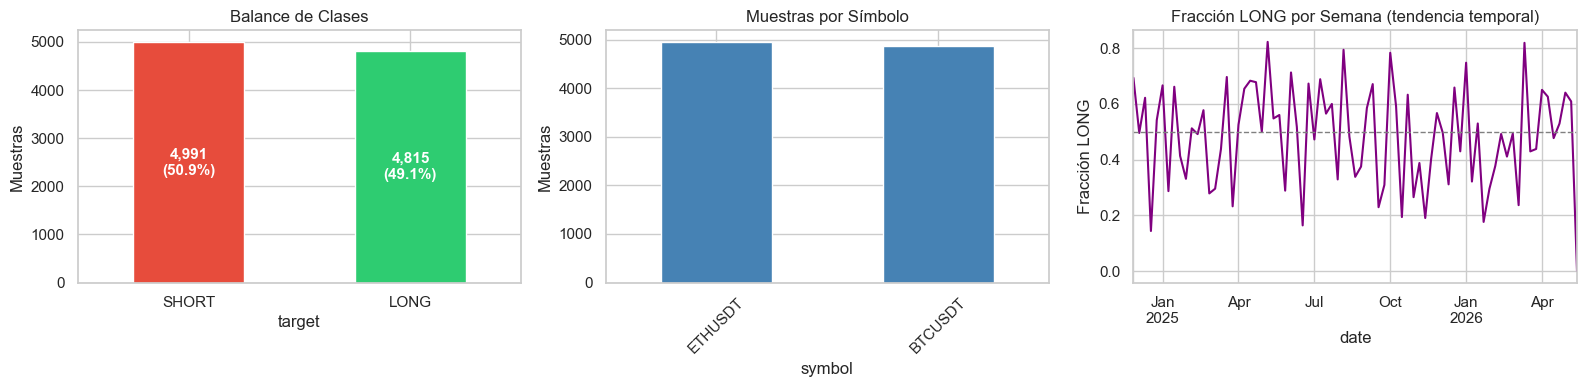


Balance: LONG=4815 (49.1%)  SHORT=4991 (50.9%)
→ Dataset prácticamente balanceado. No se requiere re-muestreo.


In [30]:
# ── Balance de clases y distribución de símbolos ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Balance
target_counts = df['target'].value_counts().rename({0:'SHORT',1:'LONG'})
target_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='white')
axes[0].set_title('Balance de Clases')
axes[0].set_ylabel('Muestras')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,}\n({p.get_height()/len(df)*100:.1f}%)',
                     (p.get_x()+p.get_width()/2, p.get_height()/2),
                     ha='center', va='center', color='white', fontweight='bold')

# Símbolos
sym_counts = df['symbol'].value_counts()
sym_counts.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Muestras por Símbolo')
axes[1].set_ylabel('Muestras')
axes[1].tick_params(axis='x', rotation=45)

# Distribución temporal
df['date'] = pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('date')['target'].resample('W').mean().plot(ax=axes[2], color='purple', linewidth=1.5)
axes[2].set_title('Fracción LONG por Semana (tendencia temporal)')
axes[2].set_ylabel('Fracción LONG')
axes[2].axhline(0.5, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

print(f'\nBalance: LONG={target_counts["LONG"]} ({target_counts["LONG"]/len(df)*100:.1f}%)  '
      f'SHORT={target_counts["SHORT"]} ({target_counts["SHORT"]/len(df)*100:.1f}%)')
print('→ Dataset prácticamente balanceado. No se requiere re-muestreo.')

## 2. Construcción de Características

Esta sección implementa tres tipos de ingeniería de características:  
1. **Análisis del conjunto original** — identificar redundancias y problemas de escala  
2. **Codificación de variables categóricas** — selección y justificación de técnica  
3. **Creación de nuevas características** — basadas en conocimiento del dominio financiero  

### 2.1 Características Actuales

In [31]:
# ── Inventario de features actuales ──────────────────────────────────────────
meta_cols = ['timestamp','date','symbol','atr_raw','target']
raw_cols  = [c for c in df.columns if not c.startswith(('heatmap_raw','structure_raw'))
             and c not in meta_cols]

numeric_cols     = [c for c in raw_cols if df[c].dtype != object]
categorical_cols = [c for c in df.columns if 'raw' in c]

print(f'Features numéricas actuales: {len(numeric_cols)}')
print(f'Features categóricas (raw):  {len(categorical_cols)}')
print(f'\nFeatures por timeframe:')
for tf in TFS:
    tf_feats = [c for c in numeric_cols if c.endswith(f'_{tf}')]
    print(f'  {tf}: {tf_feats}')
print(f'\nFeatures cross-TF: bullish_count, rsi_spread, vol_ratio_spread')

# Estadísticas básicas — solo features numéricas de indicadores
ind_cols = [c for c in numeric_cols if any(c.endswith(f'_{tf}') for tf in TFS)
            and not c.startswith('price')]
df[ind_cols[:14]].describe().round(3)

Features numéricas actuales: 30
Features categóricas (raw):  7

Features por timeframe:
  15m: ['price_15m', 'rsi_15m', 'macd_hist_15m', 'adx_15m', 'volume_ratio_15m', 'atr_ratio_15m', 'bb_pos_15m', 'heatmap_15m', 'structure_15m']
  1h: ['price_1h', 'rsi_1h', 'macd_hist_1h', 'adx_1h', 'volume_ratio_1h', 'atr_ratio_1h', 'bb_pos_1h', 'heatmap_1h', 'structure_1h']
  4h: ['price_4h', 'rsi_4h', 'macd_hist_4h', 'adx_4h', 'volume_ratio_4h', 'atr_ratio_4h', 'bb_pos_4h', 'heatmap_4h', 'structure_4h']

Features cross-TF: bullish_count, rsi_spread, vol_ratio_spread


,rsi_15m,macd_hist_15m,adx_15m,volume_ratio_15m,atr_ratio_15m,bb_pos_15m,heatmap_15m,structure_15m,rsi_1h,macd_hist_1h,adx_1h,volume_ratio_1h,atr_ratio_1h,bb_pos_1h
count,9806.0000,9806.0000,9806.0000,9806.0000,9806.0000,9806.0000,9806.0000,9806.0000,9806.0000,9806.0000,9806.0000,9806.0000,9806.0000,9806.0000
mean,50.2690,-0.0610,28.0570,1.1800,1.0470,0.5020,2.0050,1.0600,50.2590,1.7040,28.8990,1.2170,1.0390,0.5050
std,12.4930,59.4370,11.4420,0.8870,0.1890,0.3510,1.2140,1.0830,13.2430,117.3230,11.0170,0.8420,0.1780,0.3630
min,11.9480,-419.1330,6.8930,0.1590,0.6770,-0.4880,0.0000,0.0000,9.1510,-929.5630,15.0050,0.5000,0.6380,-0.5390
25%,41.7090,-6.8040,19.4390,0.6510,0.9140,0.2250,2.0000,0.0000,41.1450,-12.7680,20.5040,0.6860,0.9140,0.2150
50%,50.1550,-0.0460,25.9460,0.9370,1.0030,0.5070,2.0000,2.0000,50.0490,0.3000,25.9110,0.9380,1.0170,0.5110
75%,58.7660,6.2450,34.6390,1.4130,1.1370,0.7820,3.0000,2.0000,59.5810,14.6690,34.4320,1.4330,1.1310,0.7990
max,94.0280,653.1500,78.2620,11.7400,2.5020,1.5560,4.0000,3.0000,93.5300,884.8890,83.3540,9.9430,2.4970,1.5230


### 2.2 Codificación de Variables Categóricas

El dataset contiene dos variables categóricas por timeframe: `heatmap` y `structure`.

**`heatmap`** → **Codificación Ordinal** (justificación: existe un orden inherente y semánticamente significativo: `STRONG_BEARISH < BEARISH < NEUTRAL < BULLISH < STRONG_BULLISH`. La diferencia entre categorías adyacentes representa un incremento real de presión alcista.)

**`structure`** → **One-Hot Encoding** (justificación: las categorías `BEARISH`, `RANGE`, `BULLISH` y `BREAKOUT` no tienen un orden cardinal inequívoco. En particular, `BREAKOUT` no es necesariamente "más" que `BULLISH`; es cualitativamente distinto. La codificación ordinal introduciría una relación de orden ficticia que sesgaría modelos lineales y de distancia.)

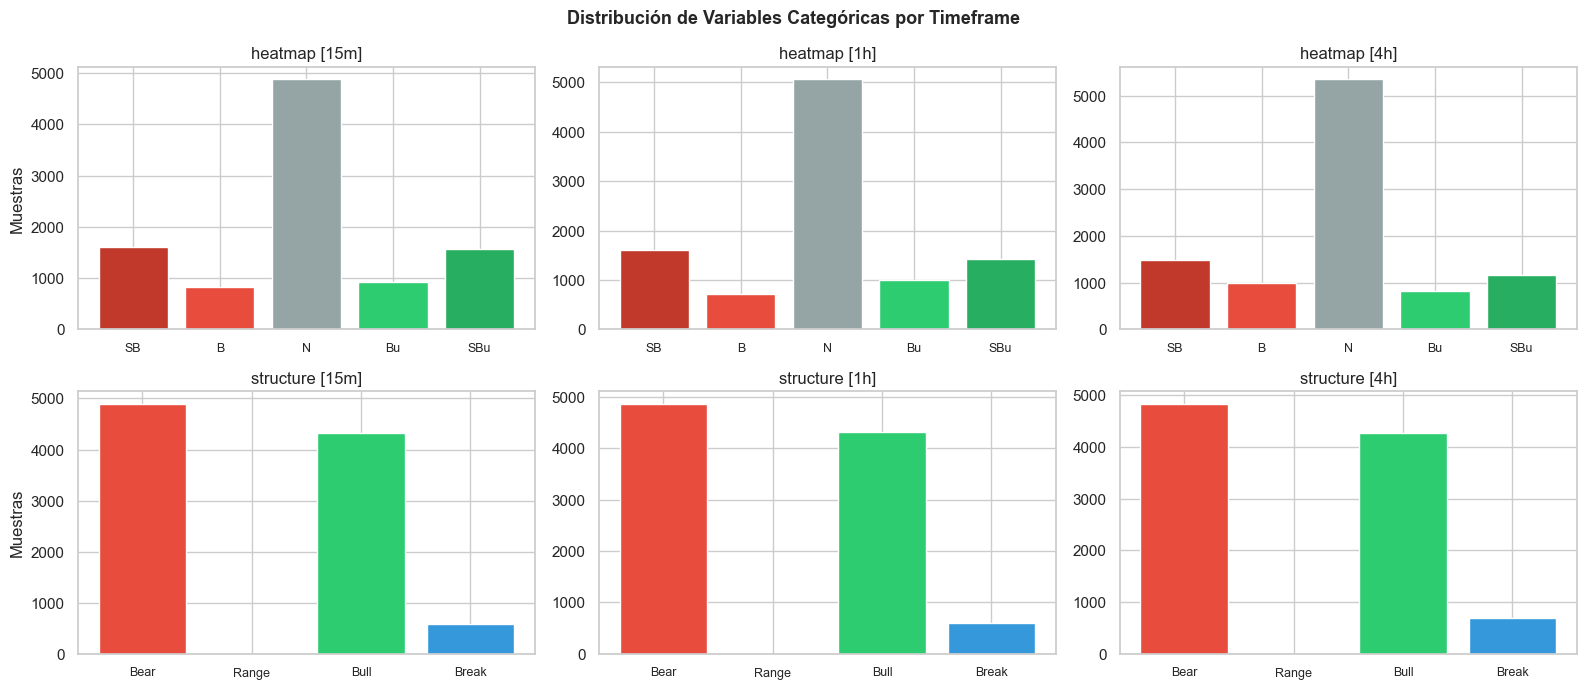

In [32]:
# ── Distribución de categorías por TF ─────────────────────────────────────────
fig, axes = plt.subplots(2, N_TFS, figsize=(16, 7))

for i, tf in enumerate(TFS):
    # Heatmap ordinal
    hm_counts = df[f'heatmap_raw_{tf}'].value_counts().reindex(
        ['STRONG_BEARISH','BEARISH','NEUTRAL','BULLISH','STRONG_BULLISH'], fill_value=0)
    colors = ['#c0392b','#e74c3c','#95a5a6','#2ecc71','#27ae60']
    axes[0,i].bar(range(len(hm_counts)), hm_counts.values, color=colors, edgecolor='white')
    axes[0,i].set_title(f'heatmap [{tf}]')
    axes[0,i].set_xticks(range(5))
    axes[0,i].set_xticklabels(['SB','B','N','Bu','SBu'], fontsize=9)
    axes[0,i].set_ylabel('Muestras' if i==0 else '')

    # Structure
    st_counts = df[f'structure_raw_{tf}'].value_counts().reindex(
        ['BEARISH','RANGE','BULLISH','BREAKOUT'], fill_value=0)
    axes[1,i].bar(range(len(st_counts)), st_counts.values,
                  color=['#e74c3c','#95a5a6','#2ecc71','#3498db'], edgecolor='white')
    axes[1,i].set_title(f'structure [{tf}]')
    axes[1,i].set_xticks(range(4))
    axes[1,i].set_xticklabels(['Bear','Range','Bull','Break'], fontsize=9)
    axes[1,i].set_ylabel('Muestras' if i==0 else '')

plt.suptitle('Distribución de Variables Categóricas por Timeframe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# ── One-Hot Encoding para 'structure' ─────────────────────────────────────────
structure_cats = ['BEARISH','RANGE','BULLISH','BREAKOUT']

for tf in TFS:
    for cat in structure_cats:
        df[f'structure_{cat.lower()}_{tf}'] = (df[f'structure_raw_{tf}'] == cat).astype(int)

ohe_structure_cols = [c for c in df.columns if any(
    c.startswith(f'structure_{cat.lower()}_') for cat in structure_cats)]

print(f'Columnas OHE generadas para structure: {len(ohe_structure_cols)}')
print(ohe_structure_cols)
print(f'\nVerificación (deben sumar 1 por fila):')
check = df[[f'structure_{cat.lower()}_{TFS[0]}' for cat in structure_cats]].sum(axis=1)
print(f'  Min={check.min()}, Max={check.max()}, Mean={check.mean():.3f}  ✓')

Columnas OHE generadas para structure: 12
['structure_bearish_15m', 'structure_range_15m', 'structure_bullish_15m', 'structure_breakout_15m', 'structure_bearish_1h', 'structure_range_1h', 'structure_bullish_1h', 'structure_breakout_1h', 'structure_bearish_4h', 'structure_range_4h', 'structure_bullish_4h', 'structure_breakout_4h']

Verificación (deben sumar 1 por fila):
  Min=1, Max=1, Mean=1.000  ✓


### 2.3 Nuevas Características Numéricas

Se crean 11 nuevas características basadas en conocimiento del dominio financiero. Cada una está justificada:

In [34]:
# ── 1. Divergencia RSI entre timeframes ───────────────────────────────────────
# Justificación: Cuando el RSI del TF corto diverge del TF largo, anticipa reversiones
# o continuaciones de tendencia. Es un indicador clásico de análisis técnico multi-TF.
tf_short, tf_mid, tf_long = TFS[0], TFS[1], TFS[2]  # 15m, 1h, 4h

df['rsi_div_short_long'] = df[f'rsi_{tf_short}'] - df[f'rsi_{tf_long}']
df['rsi_div_mid_long']   = df[f'rsi_{tf_mid}']   - df[f'rsi_{tf_long}']
# Valor positivo → TF corto más sobrecomprado que el largo (posible corrección)

# ── 2. Porcentaje de TFs alcistas ─────────────────────────────────────────────
# Justificación: Normaliza bullish_count a [0,1]; facilita comparación y mejora
# la convergencia en LSTM vs la variable entera.
df['trend_agreement_pct'] = df['bullish_count'] / N_TFS

# ── 3. Momentum MACD × ADX ────────────────────────────────────────────────────
# Justificación: El histograma MACD indica dirección del momentum, pero su magnitud
# varía enormemente entre símbolos. Multiplicar por ADX (fuerza de tendencia) y
# normalizar por 100 crea un indicador de momentum direccional comparable.
for tf in TFS:
    df[f'macd_momentum_{tf}'] = (np.sign(df[f'macd_hist_{tf}']) *
                                  df[f'adx_{tf}'] / 100.0)

# ── 4. Posición relativa en Bollinger Bands ───────────────────────────────────
# Justificación: bb_pos puede ser >1 o <0 (precio fuera de bandas). La distancia
# al centro (0.5) mide cuánto se ha estirado el precio → reversal signal.
for tf in TFS:
    df[f'bb_distance_center_{tf}'] = df[f'bb_pos_{tf}'] - 0.5  # >0: zona alta, <0: zona baja

# ── 5. Spread de ATR entre TFs ────────────────────────────────────────────────
# Justificación: Cuando la volatilidad de TF corto (15m) supera a la de TF largo (4h),
# indica aumento local de volatilidad → potencial breakout inminente.
df['atr_ratio_spread'] = df[f'atr_ratio_{tf_short}'] - df[f'atr_ratio_{tf_long}']

# ── 6. Alineación RSI multi-TF ────────────────────────────────────────────────
# Justificación: Variable binaria que indica si todos los TFs están en la misma
# zona RSI (>50 alcista / <50 bajista). Alta alineación → señal más fiable.
rsi_sides = [(df[f'rsi_{tf}'] > 50).astype(int) for tf in TFS]
df['rsi_alignment'] = (rsi_sides[0] == rsi_sides[1]).astype(int) & \
                      (rsi_sides[1] == rsi_sides[2]).astype(int)

# ── 7. Características temporales (codificación cíclica) ──────────────────────
# Justificación: Los mercados de cripto tienen patrones horarios (apertura NY/Londres)
# y semanales (fines de semana suelen tener menor volumen). La codificación sin/cos
# preserva la continuidad cíclica (23h está cerca de 0h).
dt = pd.to_datetime(df['timestamp'], unit='ms', utc=True)
hour = dt.dt.hour
dow  = dt.dt.dayofweek  # 0=lunes, 6=domingo

df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
df['dow_sin']  = np.sin(2 * np.pi * dow  / 7)
df['dow_cos']  = np.cos(2 * np.pi * dow  / 7)

# ── Resumen ───────────────────────────────────────────────────────────────────
new_features = (['rsi_div_short_long','rsi_div_mid_long','trend_agreement_pct','rsi_alignment',
                 'atr_ratio_spread'] +
                [f'macd_momentum_{tf}' for tf in TFS] +
                [f'bb_distance_center_{tf}' for tf in TFS] +
                ['hour_sin','hour_cos','dow_sin','dow_cos'])

print(f'Nuevas características creadas: {len(new_features)}')
for f in new_features:
    print(f'  {f:40s}  μ={df[f].mean():.4f}  σ={df[f].std():.4f}')

Nuevas características creadas: 15
  rsi_div_short_long                        μ=-0.0204  σ=13.1249
  rsi_div_mid_long                          μ=-0.0308  σ=8.8672
  trend_agreement_pct                       μ=0.2343  σ=0.3364
  rsi_alignment                             μ=0.6187  σ=0.4857
  atr_ratio_spread                          μ=0.0260  σ=0.2307
  macd_momentum_15m                         μ=-0.0030  σ=0.3030
  macd_momentum_1h                          μ=0.0052  σ=0.3092
  macd_momentum_4h                          μ=0.0024  σ=0.2977
  bb_distance_center_15m                    μ=0.0021  σ=0.3505
  bb_distance_center_1h                     μ=0.0049  σ=0.3629
  bb_distance_center_4h                     μ=0.0066  σ=0.3622
  hour_sin                                  μ=-0.0657  σ=0.7039
  hour_cos                                  μ=-0.0670  σ=0.7042
  dow_sin                                   μ=0.0570  σ=0.6817
  dow_cos                                   μ=0.0086  σ=0.7294


In [35]:
# ── 2.4 Resumen del conjunto de features final ─────────────────────────────────
# Definir conjunto completo (excluyendo metadata y raw categoricals)
ORIGINAL_NUMERIC = []
for tf in TFS:
    ORIGINAL_NUMERIC += [f'{k}_{tf}' for k in NUMERIC_KEYS]
ORIGINAL_NUMERIC += ['bullish_count','rsi_spread','vol_ratio_spread']

HEATMAP_ORDINAL  = [f'heatmap_{tf}' for tf in TFS]        # Ordinal (0-4)
STRUCTURE_OHE    = ohe_structure_cols                       # OHE (binary)
NEW_FEATURES     = new_features

ALL_FEATURES = ORIGINAL_NUMERIC + HEATMAP_ORDINAL + STRUCTURE_OHE + NEW_FEATURES
TARGET = 'target'

print('══════════════════════════════════════════════')
print(f'  Features originales numéricas : {len(ORIGINAL_NUMERIC)}')
print(f'  Heatmap ordinal (3 TFs)       : {len(HEATMAP_ORDINAL)}')
print(f'  Structure OHE (4 cat × 3 TFs) : {len(STRUCTURE_OHE)}')
print(f'  Nuevas características         : {len(NEW_FEATURES)}')
print(f'  ─────────────────────────────────────────')
print(f'  TOTAL features                : {len(ALL_FEATURES)}')
print('══════════════════════════════════════════════')

X_raw = df[ALL_FEATURES].values.astype(np.float32)
y     = df[TARGET].values
print(f'\nX_raw shape: {X_raw.shape}  |  y shape: {y.shape}')

══════════════════════════════════════════════
  Features originales numéricas : 24
  Heatmap ordinal (3 TFs)       : 3
  Structure OHE (4 cat × 3 TFs) : 12
  Nuevas características         : 15
  ─────────────────────────────────────────
  TOTAL features                : 54
══════════════════════════════════════════════

X_raw shape: (9806, 54)  |  y shape: (9806,)


## 3. Normalización

El escalado y la transformación son **críticos especialmente para LSTM** (gradientes sensibles a magnitudes), y útiles para PCA y métodos de filtrado basados en distancia. Para modelos de árbol (XGBoost, RF) el escalado no afecta el rendimiento pero sí la interpretabilidad de los resultados comparativos.

### 3.1 Análisis de Distribuciones Pre-Escalado

In [36]:
# ── Análisis de asimetría y curtosis ──────────────────────────────────────────
# Solo features numéricas de indicadores (excluir OHE y temporales)
analysis_cols = [c for c in ORIGINAL_NUMERIC + NEW_FEATURES
                 if c not in ['bullish_count','rsi_alignment'] and
                 not any(c.startswith(p) for p in ['hour','dow'])]

skew_df = pd.DataFrame({
    'Asimetría':  df[analysis_cols].skew(),
    'Curtosis':   df[analysis_cols].kurt(),
    'Min':        df[analysis_cols].min(),
    'Max':        df[analysis_cols].max(),
    'Media':      df[analysis_cols].mean(),
    'Std':        df[analysis_cols].std(),
}).round(3)

skew_df['Tipo_distribución'] = skew_df['Asimetría'].apply(
    lambda s: 'Muy sesgada +' if s > 2 else
              'Sesgada +'    if s > 1 else
              'Muy sesgada -' if s < -2 else
              'Sesgada -'    if s < -1 else 'Aprox. Normal'
)
print(skew_df.sort_values('Asimetría', ascending=False).to_string())

                        Asimetría  Curtosis        Min         Max      Media        Std Tipo_distribución
volume_ratio_15m           3.5750   22.9760     0.1590     11.7400     1.1800     0.8870     Muy sesgada +
volume_ratio_1h            2.9580   14.1560     0.5000      9.9430     1.2170     0.8420     Muy sesgada +
vol_ratio_spread           2.8300   14.3000     0.0040     10.0260     0.8800     0.7940     Muy sesgada +
volume_ratio_4h            1.9020    6.3180     0.1570      7.5640     1.1950     0.7480         Sesgada +
atr_ratio_15m              1.4000    3.1610     0.6770      2.5020     1.0470     0.1890         Sesgada +
trend_agreement_pct        1.1730    0.0190     0.0000      1.0000     0.2340     0.3360         Sesgada +
adx_1h                     1.1710    1.0800    15.0050     83.3540    28.8990    11.0170         Sesgada +
atr_ratio_1h               1.0910    2.9190     0.6380      2.4970     1.0390     0.1780         Sesgada +
adx_4h                     0.9680    

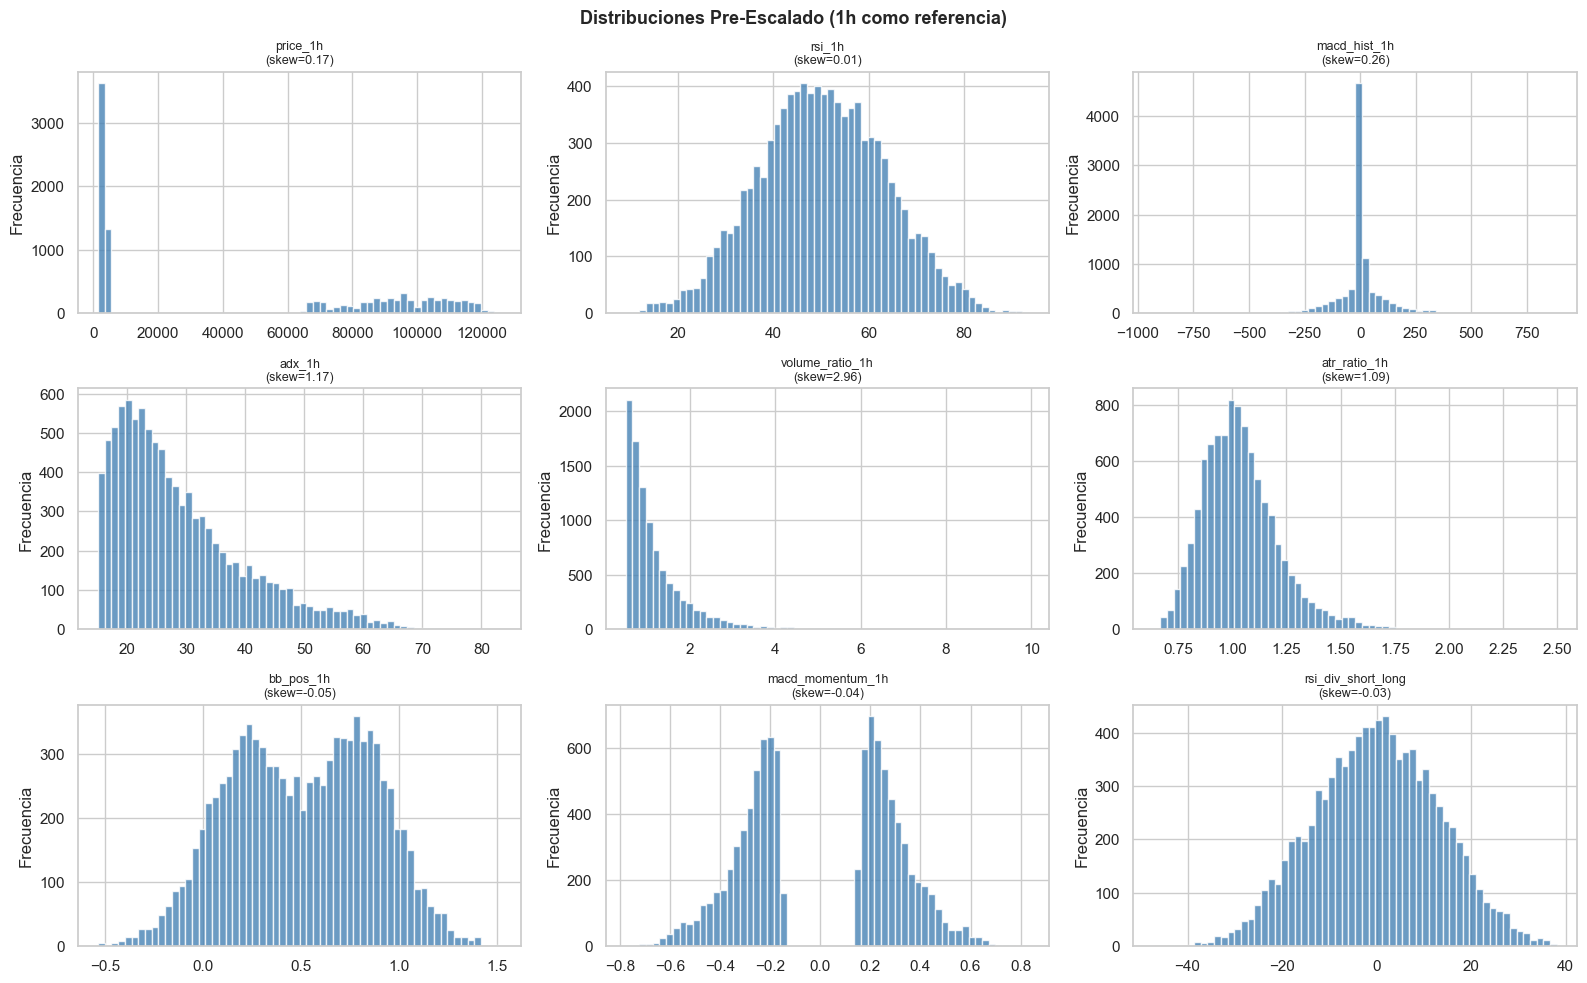


Observaciones clave:
  • price_1h: escala absoluta (~BTC=93k, ETH=3.5k) → ELIMINAR
  • volume_ratio / atr_ratio: fuerte sesgo positivo → transformación logarítmica
  • macd_hist: sin límite, centrado en 0, colas pesadas → StandardScaler
  • rsi / adx: acotadas [0,100] → MinMaxScaler
  • bb_pos: puede salir del rango [0,1] → StandardScaler


In [37]:
# ── Histogramas de features representativas ────────────────────────────────────
showcase = [
    f'price_{tf_mid}', f'rsi_{tf_mid}', f'macd_hist_{tf_mid}',
    f'adx_{tf_mid}', f'volume_ratio_{tf_mid}', f'atr_ratio_{tf_mid}',
    f'bb_pos_{tf_mid}', f'macd_momentum_{tf_mid}', 'rsi_div_short_long'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, showcase):
    data = df[col].dropna()
    ax.hist(data, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'{col}\n(skew={data.skew():.2f})', fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribuciones Pre-Escalado (1h como referencia)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nObservaciones clave:')
print(f'  • price_{tf_mid}: escala absoluta (~BTC=93k, ETH=3.5k) → ELIMINAR')
print(f'  • volume_ratio / atr_ratio: fuerte sesgo positivo → transformación logarítmica')
print(f'  • macd_hist: sin límite, centrado en 0, colas pesadas → StandardScaler')
print(f'  • rsi / adx: acotadas [0,100] → MinMaxScaler')
print(f'  • bb_pos: puede salir del rango [0,1] → StandardScaler')

### 3.2 Estrategia de Normalización

| Grupo | Features | Técnica | Justificación |
|-------|----------|---------|---------------|
| Precio absoluto | `price_*` | **Eliminar** | Escala depende del símbolo → sesga modelos; `bb_pos` y `atr_ratio` ya codifican posición relativa |
| RSI, ADX | `rsi_*`, `adx_*` | **MinMaxScaler** | Rango fijo por definición (0-100); solo se escala a [0,1] |
| MACD, bb_pos | `macd_hist_*`, `bb_pos_*`, divergencias RSI | **StandardScaler** | Sin límites claros; distribución aproximadamente simétrica |
| Volume ratio, ATR ratio | `volume_ratio_*`, `atr_ratio_*` | **Yeo-Johnson** | Fuerte sesgo positivo; Yeo-Johnson maneja valores negativos (a diferencia de Box-Cox) |
| Momentum MACD×ADX | `macd_momentum_*` | **StandardScaler** | Derivada de sign() × ADX, centrada en 0 |
| Temporales sin/cos | `hour_*`, `dow_*` | **Sin escalar** | Ya en [-1, 1] por definición |
| Categoriales OHE | `structure_*` | **Sin escalar** | Binarias (0/1) |
| Heatmap ordinal | `heatmap_*` | **Sin escalar** | Entero 0-4, se deja para preservar ordenamiento |

In [38]:
# ── Split temporal (mismo que en entrenamiento de modelos) ────────────────────
# CRÍTICO: el scaler se ajusta SOLO sobre datos de entrenamiento para evitar
# data leakage hacia validación y test.
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_df = df[ALL_FEATURES].copy()
X_train_raw = X_df.iloc[:train_end]
X_val_raw   = X_df.iloc[train_end:val_end]
X_test_raw  = X_df.iloc[val_end:]
y_train = y[:train_end]
y_val   = y[train_end:val_end]
y_test  = y[val_end:]

print(f'Train : {len(X_train_raw):>6,} muestras ({len(X_train_raw)/n*100:.0f}%)')
print(f'Val   : {len(X_val_raw):>6,} muestras ({len(X_val_raw)/n*100:.0f}%)')
print(f'Test  : {len(X_test_raw):>6,} muestras ({len(X_test_raw)/n*100:.0f}%)  [NO se usa en este notebook]')

Train :  6,864 muestras (70%)
Val   :  1,471 muestras (15%)
Test  :  1,471 muestras (15%)  [NO se usa en este notebook]


In [39]:
# ── Definir grupos de features para ColumnTransformer ────────────────────────
price_cols = [f'price_{tf}' for tf in TFS]  # A eliminar

minmax_cols = ([f'rsi_{tf}' for tf in TFS] +
               [f'adx_{tf}' for tf in TFS] +
               ['trend_agreement_pct', 'rsi_alignment'])

standard_cols = ([f'macd_hist_{tf}' for tf in TFS] +
                 [f'bb_pos_{tf}' for tf in TFS] +
                 [f'bb_distance_center_{tf}' for tf in TFS] +
                 [f'macd_momentum_{tf}' for tf in TFS] +
                 ['rsi_div_short_long', 'rsi_div_mid_long',
                  'rsi_spread', 'vol_ratio_spread', 'atr_ratio_spread',
                  'bullish_count'])

yeojohnson_cols = ([f'volume_ratio_{tf}' for tf in TFS] +
                   [f'atr_ratio_{tf}' for tf in TFS])

# Sin escalar: heatmap ordinal, structure OHE, temporales
passthrough_cols = (HEATMAP_ORDINAL + STRUCTURE_OHE +
                    ['hour_sin','hour_cos','dow_sin','dow_cos'])

# Verificar que cubrimos todas las features
all_assigned = set(price_cols + minmax_cols + standard_cols +
                   yeojohnson_cols + passthrough_cols)
missing = set(ALL_FEATURES) - all_assigned
extra   = all_assigned - set(ALL_FEATURES)
print(f'Features sin asignar grupo: {missing}')
print(f'Features en grupo pero no en ALL_FEATURES: {extra}')
print(f'\nGrupo MinMaxScaler    : {len(minmax_cols)} features')
print(f'Grupo StandardScaler  : {len(standard_cols)} features')
print(f'Grupo Yeo-Johnson     : {len(yeojohnson_cols)} features')
print(f'Grupo pass-through    : {len(passthrough_cols)} features')
print(f'Eliminadas (price)    : {len(price_cols)} features')

Features sin asignar grupo: set()
Features en grupo pero no en ALL_FEATURES: set()

Grupo MinMaxScaler    : 8 features
Grupo StandardScaler  : 18 features
Grupo Yeo-Johnson     : 6 features
Grupo pass-through    : 19 features
Eliminadas (price)    : 3 features


In [40]:
# ── Construir y ajustar ColumnTransformer ─────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('minmax',      MinMaxScaler(),                    minmax_cols),
        ('standard',    StandardScaler(),                  standard_cols),
        ('yeojohnson',  PowerTransformer('yeo-johnson'),   yeojohnson_cols),
        ('passthrough', 'passthrough',                     passthrough_cols),
        # price_cols no aparecen → son descartadas automáticamente
    ],
    remainder='drop'   # Descarta price_cols y cualquier no listada
)

# Ajuste SOLO en datos de entrenamiento
X_train_scaled = preprocessor.fit_transform(X_train_raw)
X_val_scaled   = preprocessor.transform(X_val_raw)

# Nombres de features transformadas
feature_names_scaled = (minmax_cols + standard_cols + yeojohnson_cols + passthrough_cols)
N_FEATURES_SCALED = len(feature_names_scaled)

print(f'Shape post-escalado: train={X_train_scaled.shape}, val={X_val_scaled.shape}')
print(f'Número de features finales: {N_FEATURES_SCALED} (se eliminaron {len(price_cols)} price_*)')

# DataFrame para análisis
df_scaled = pd.DataFrame(
    np.vstack([X_train_scaled, X_val_scaled]),
    columns=feature_names_scaled
)

Shape post-escalado: train=(6864, 51), val=(1471, 51)
Número de features finales: 51 (se eliminaron 3 price_*)


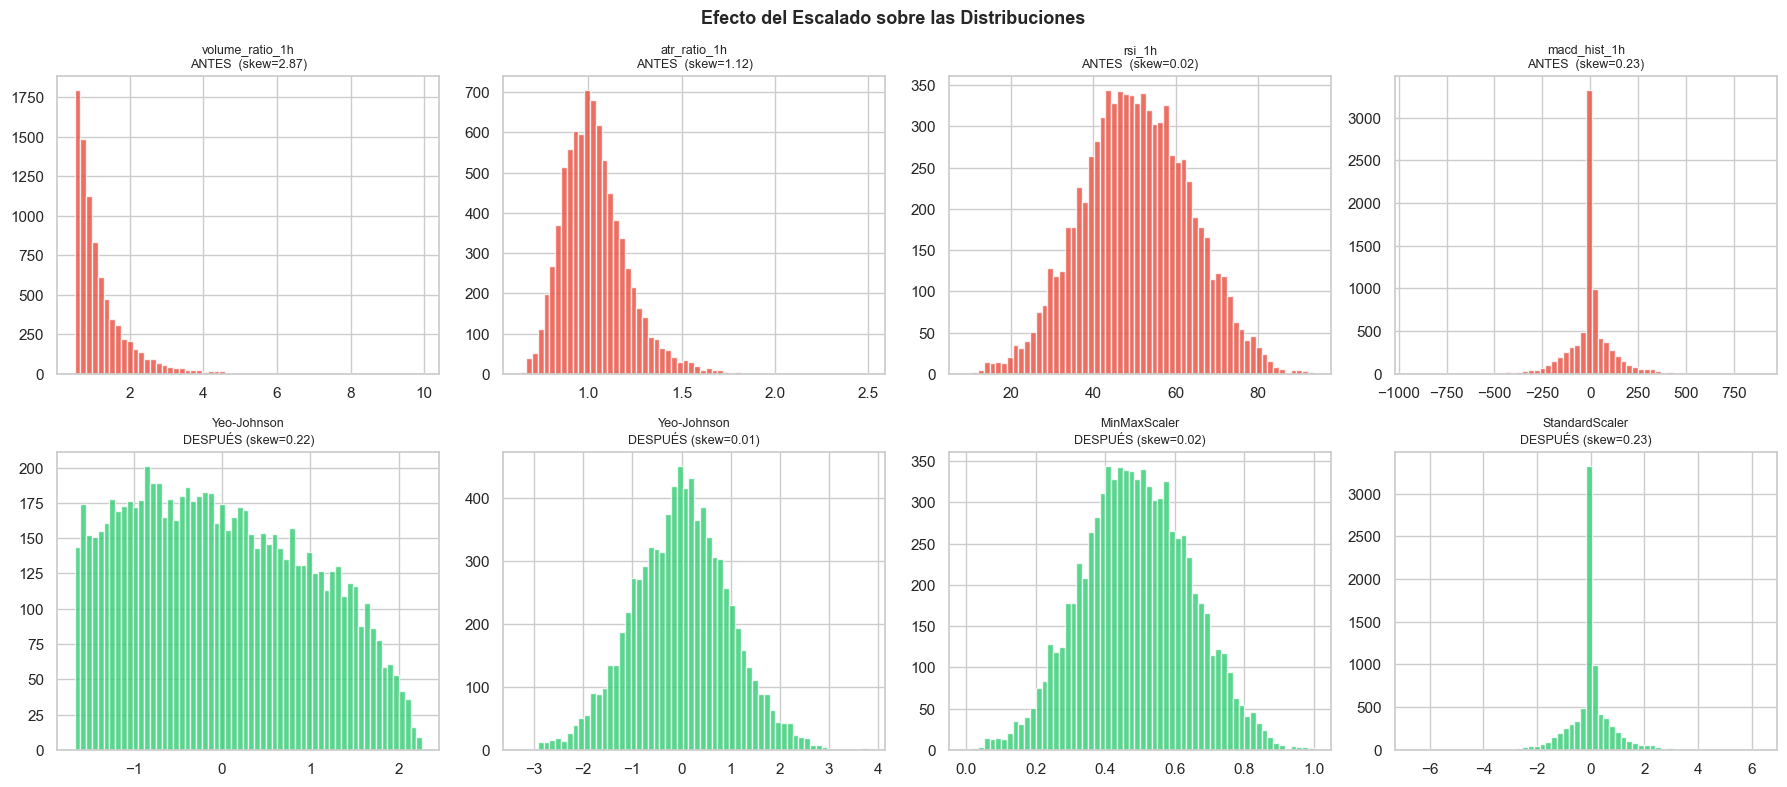

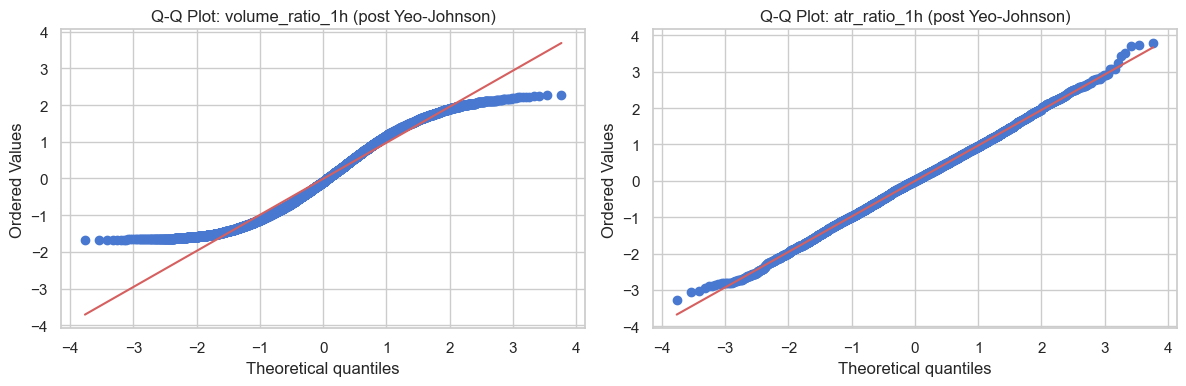

In [41]:
# ── Verificación: distribuciones antes y después del escalado ─────────────────
compare_pairs = [
    (f'volume_ratio_{tf_mid}', 'Yeo-Johnson'),
    (f'atr_ratio_{tf_mid}',    'Yeo-Johnson'),
    (f'rsi_{tf_mid}',          'MinMaxScaler'),
    (f'macd_hist_{tf_mid}',    'StandardScaler'),
]

fig, axes = plt.subplots(2, len(compare_pairs), figsize=(18, 8))

for j, (col, method) in enumerate(compare_pairs):
    original = df[col].values[:train_end + val_end - train_end]
    scaled   = df_scaled[col].values if col in df_scaled.columns else np.zeros(1)

    axes[0, j].hist(original, bins=60, color='#e74c3c', edgecolor='white', alpha=0.8)
    axes[0, j].set_title(f'{col}\nANTES  (skew={pd.Series(original).skew():.2f})', fontsize=9)

    if col in df_scaled.columns:
        axes[1, j].hist(scaled, bins=60, color='#2ecc71', edgecolor='white', alpha=0.8)
        axes[1, j].set_title(f'{method}\nDESPUÉS (skew={pd.Series(scaled).skew():.2f})', fontsize=9)
    else:
        axes[1, j].text(0.5, 0.5, 'N/A', ha='center', va='center', transform=axes[1,j].transAxes)

plt.suptitle('Efecto del Escalado sobre las Distribuciones', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Q-Q Plot para verificar normalidad post Yeo-Johnson
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, [f'volume_ratio_{tf_mid}', f'atr_ratio_{tf_mid}']):
    if col in df_scaled.columns:
        stats.probplot(df_scaled[col].dropna(), dist='norm', plot=ax)
        ax.set_title(f'Q-Q Plot: {col} (post Yeo-Johnson)')
plt.tight_layout()
plt.show()

## 4. Selección y Extracción de Características

Aplicamos métodos progresivos: primero filtrado (varianza, correlación, tests estadísticos), luego importancia basada en modelo, y finalmente extracción con PCA. La decisión final se basa en comparar el rendimiento del clasificador en validación.

### 4.1 Umbral de Varianza

Features originales   : 51
Eliminadas (var<0.01) : 3
Features restantes    : 48

Eliminadas:
  structure_range_15m: var=0.000582
  structure_range_1h: var=0.000000
  structure_range_4h: var=0.000000


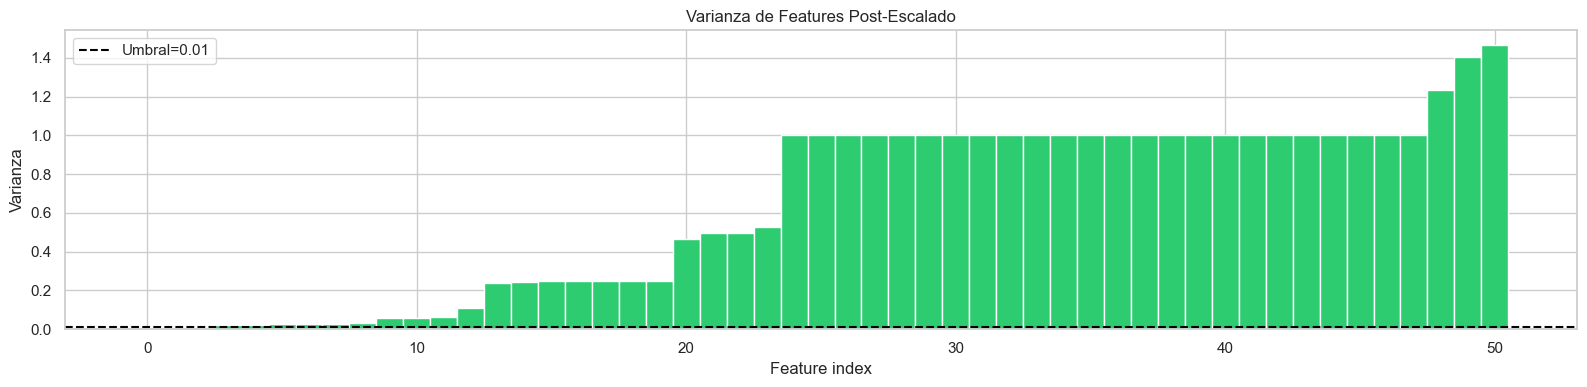

In [42]:
# Justificación: Features con varianza casi nula no aportan información discriminante
# y pueden introducir ruido. Un umbral de 0.01 elimina features prácticamente constantes.

var_selector = VarianceThreshold(threshold=0.01)
X_var = var_selector.fit_transform(X_train_scaled)

mask_var = var_selector.get_support()
removed_by_var = [feature_names_scaled[i] for i, m in enumerate(mask_var) if not m]
kept_var_names = [feature_names_scaled[i] for i, m in enumerate(mask_var) if m]

print(f'Features originales   : {len(feature_names_scaled)}')
print(f'Eliminadas (var<0.01) : {len(removed_by_var)}')
print(f'Features restantes    : {X_var.shape[1]}')

if removed_by_var:
    print(f'\nEliminadas:')
    for c in removed_by_var:
        print(f'  {c}: var={var_selector.variances_[feature_names_scaled.index(c)]:.6f}')
else:
    print('\nTodas las features superan el umbral de varianza. ✓')

# Visualizar varianzas
variances = pd.Series(var_selector.variances_, index=feature_names_scaled).sort_values()
fig, ax = plt.subplots(figsize=(16, 4))
colors = ['#e74c3c' if v < 0.01 else '#2ecc71' for v in variances.values]
ax.bar(range(len(variances)), variances.values, color=colors, width=1.0)
ax.axhline(0.01, color='black', linestyle='--', linewidth=1.5, label='Umbral=0.01')
ax.set_xlabel('Feature index')
ax.set_ylabel('Varianza')
ax.set_title('Varianza de Features Post-Escalado')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Análisis de Correlación

Features altamente correlacionadas entre sí aportan información redundante, incrementan innecesariamente la dimensionalidad y pueden inducir multicolinealidad en ciertos modelos.

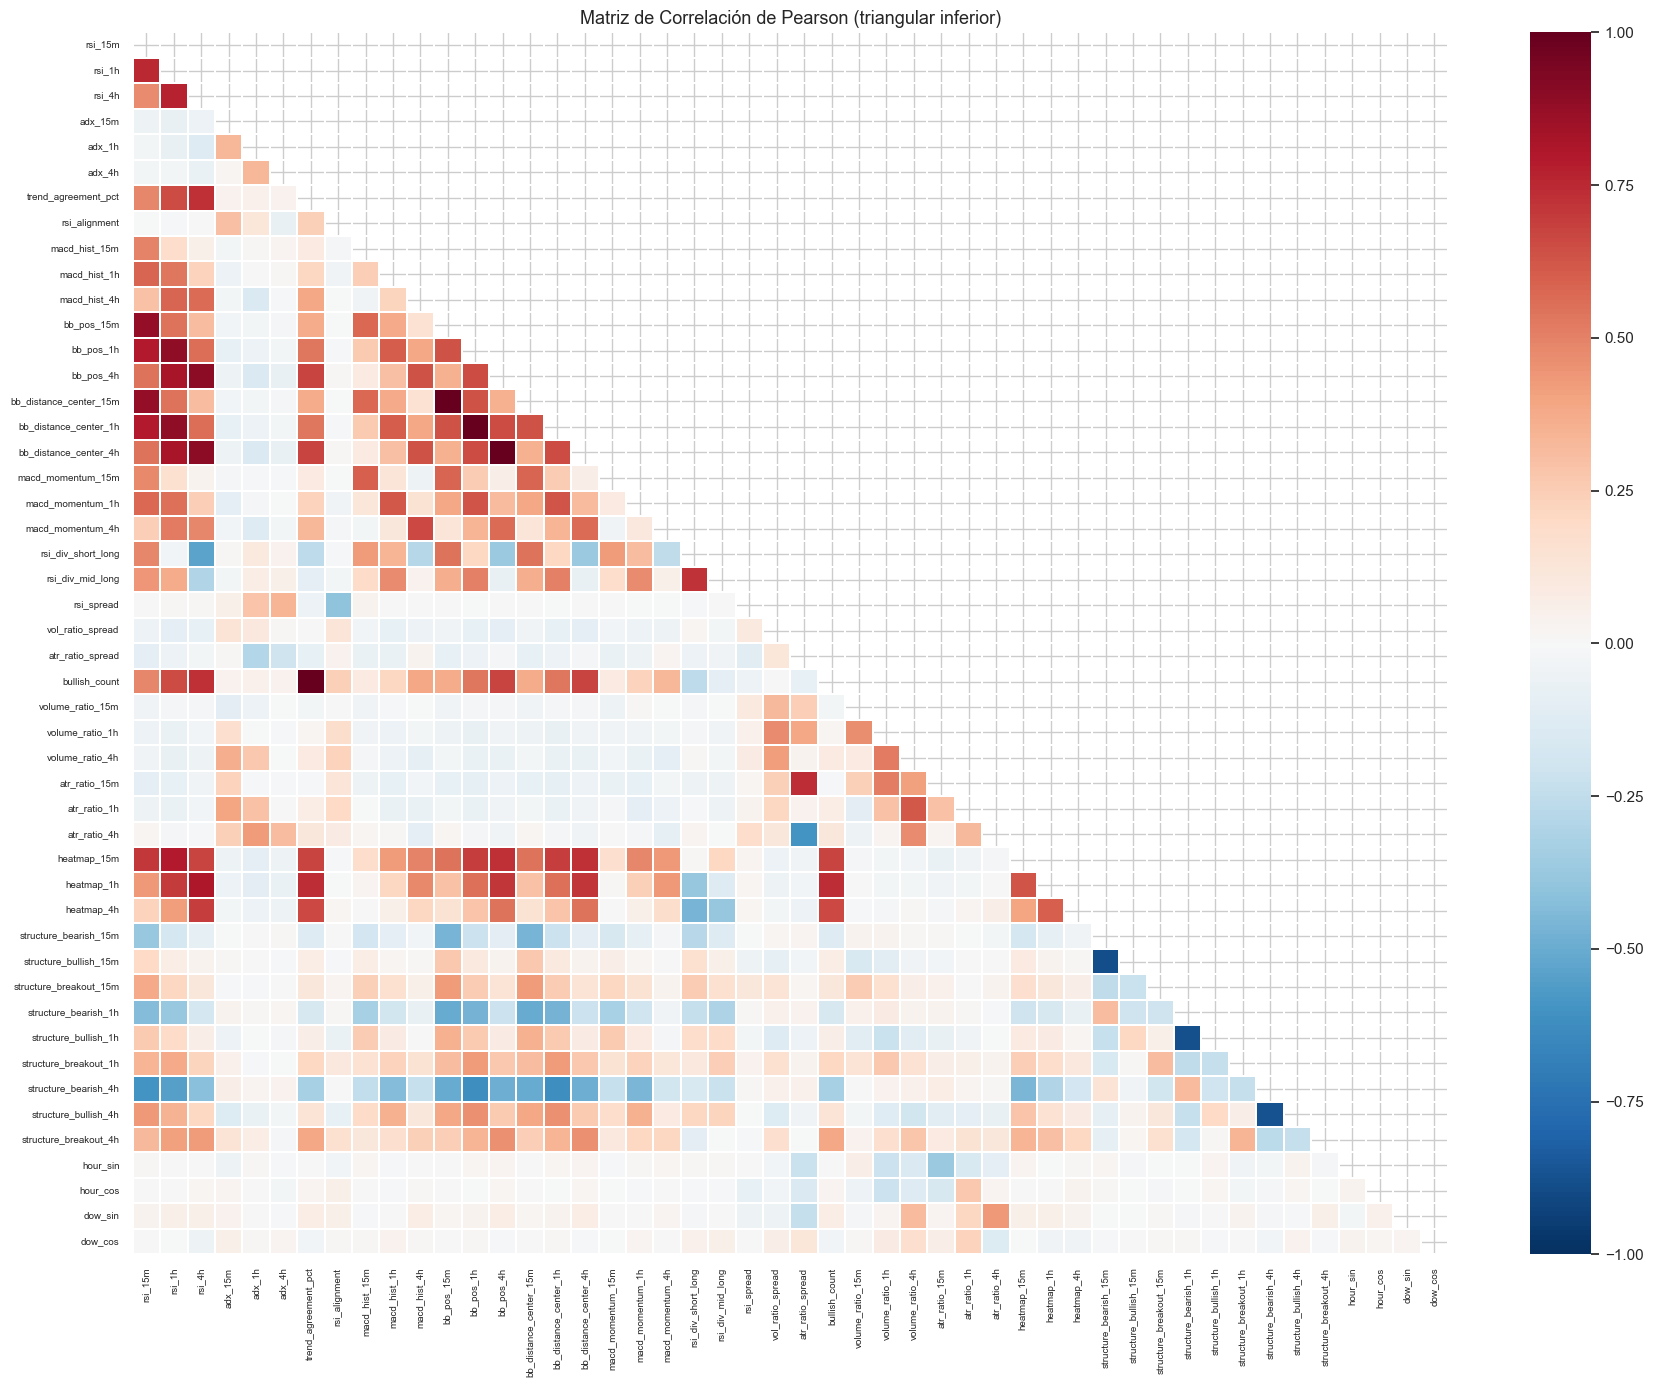

Pares con |correlacion| >= 0.9:
          Feature_A              Feature_B  Correlación
trend_agreement_pct          bullish_count       1.0000
         bb_pos_15m bb_distance_center_15m       1.0000
          bb_pos_1h  bb_distance_center_1h       1.0000
          bb_pos_4h  bb_distance_center_4h       1.0000


In [43]:
# ── Matriz de correlación de Pearson (train set) ──────────────────────────────
df_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names_scaled)
corr_matrix = df_train_scaled[kept_var_names].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask_viz = np.triu(np.ones_like(corr_matrix, dtype=bool))   # k=0: oculta diagonal en visualización
sns.heatmap(
    corr_matrix, mask=mask_viz, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.3, square=False,
    xticklabels=True, yticklabels=True, ax=ax
)
ax.set_title('Matriz de Correlación de Pearson (triangular inferior)', fontsize=13)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

# ── Identificar pares altamente correlacionados ─────────────────────────────
# k=1 excluye la diagonal principal (autocorrelación = 1.0) para evitar
# que cada feature se elimine a sí misma como redundante.
CORR_THRESHOLD = 0.90
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
upper = corr_matrix.where(mask_upper).stack()
high_corr = upper[upper.abs() >= CORR_THRESHOLD].reset_index()
high_corr.columns = ['Feature_A','Feature_B','Correlación']
high_corr = high_corr.sort_values('Correlación', ascending=False, key=abs)

print(f'Pares con |correlacion| >= {CORR_THRESHOLD}:')
if len(high_corr) == 0:
    print('  Ninguno. Todas las features son suficientemente independientes.')
else:
    print(high_corr.to_string(index=False))

In [44]:
# ── Eliminar features redundantes por correlación ─────────────────────────────
to_drop_corr = set()
for _, row in high_corr.iterrows():
    fa, fb = row['Feature_A'], row['Feature_B']
    # Eliminar la segunda (B) — heurística: conservar la que aparece primero
    if fa not in to_drop_corr:
        to_drop_corr.add(fb)

kept_after_corr = [c for c in kept_var_names if c not in to_drop_corr]
print(f'Features eliminadas por correlación (|r| ≥ {CORR_THRESHOLD}): {len(to_drop_corr)}')
for c in sorted(to_drop_corr):
    print(f'  ✗ {c}')
print(f'\nFeatures restantes después del filtro de correlación: {len(kept_after_corr)}')

Features eliminadas por correlación (|r| ≥ 0.9): 4
  ✗ bb_distance_center_15m
  ✗ bb_distance_center_1h
  ✗ bb_distance_center_4h
  ✗ bullish_count

Features restantes después del filtro de correlación: 44


### 4.3 ANOVA F-test y Chi-cuadrado

- **ANOVA F-test** (`f_classif`): mide qué tanto varía la media de cada feature entre clases LONG y SHORT. Un F alto indica alta capacidad discriminante.
- **Chi-cuadrado**: aplicado a las variables categóricas (heatmap ordinal) para medir dependencia estadística con la clase objetivo.

kept_after_corr  : 44 features
numeric_kept     : 32 features
categorical_kept : 3 features

Top 20 features por ANOVA F-Score:
           Feature  F-Score  p-valor  Significativo
  rsi_div_mid_long 374.2413   0.0000           True
         bb_pos_4h 153.8698   0.0000           True
rsi_div_short_long 146.2183   0.0000           True
            rsi_4h 129.7697   0.0000           True
      macd_hist_4h  12.1778   0.0005           True
  macd_momentum_4h   7.4193   0.0065           True
         bb_pos_1h   5.4080   0.0201           True
  macd_momentum_1h   5.2438   0.0221           True
      macd_hist_1h   4.8112   0.0283           True
            adx_4h   4.3666   0.0367           True
           dow_sin   4.1551   0.0415           True
      atr_ratio_4h   3.7567   0.0526          False
  atr_ratio_spread   3.0157   0.0825          False
            rsi_1h   2.4133   0.1204          False
 macd_momentum_15m   2.1850   0.1394          False
   volume_ratio_1h   2.1718   0.1406    

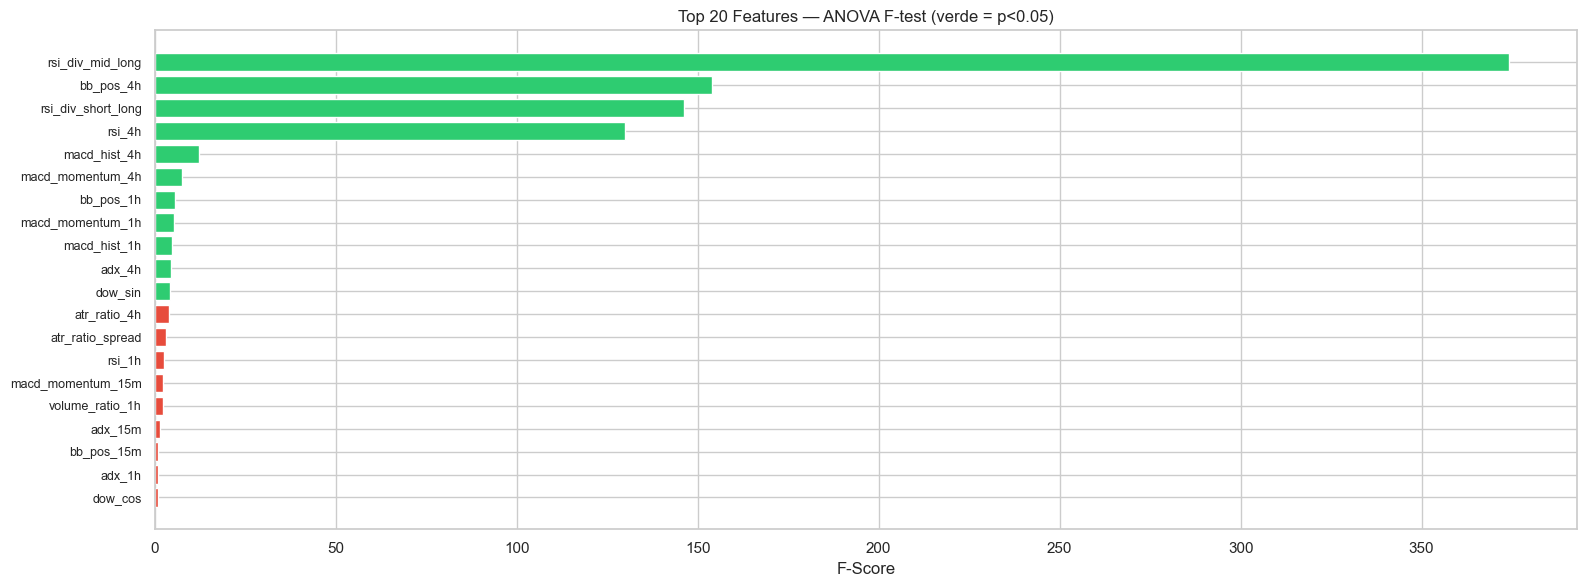

In [45]:
# ── ANOVA F-test sobre features numéricas post-escalado ───────────────────────
# Usar solo features no-OHE para ANOVA, OHE para chi2
numeric_kept     = [c for c in kept_after_corr if c not in STRUCTURE_OHE and c not in HEATMAP_ORDINAL]
categorical_kept = [c for c in kept_after_corr if c in HEATMAP_ORDINAL]

print(f'kept_after_corr  : {len(kept_after_corr)} features')
print(f'numeric_kept     : {len(numeric_kept)} features')
print(f'categorical_kept : {len(categorical_kept)} features')

if len(numeric_kept) == 0:
    msg = (
        'numeric_kept esta vacio. '
        f'kept_after_corr={len(kept_after_corr)} features. '
        'Reinicia el kernel y ejecuta TODAS las celdas en orden (Kernel -> Restart -> Run All).'
    )
    raise RuntimeError(msg)

X_num_train = df_train_scaled[numeric_kept].values
f_scores, p_values = f_classif(X_num_train, y_train)

anova_df = pd.DataFrame({
    'Feature': numeric_kept,
    'F-Score': f_scores,
    'p-valor': p_values,
    'Significativo': p_values < 0.05
}).sort_values('F-Score', ascending=False)

print()
print('Top 20 features por ANOVA F-Score:')
print(anova_df.head(20).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(16, 6))
top20 = anova_df.head(20)
colors = ['#2ecc71' if s else '#e74c3c' for s in top20['Significativo']]
ax.barh(range(len(top20)), top20['F-Score'].values[::-1], color=colors[::-1])
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['Feature'].values[::-1], fontsize=9)
ax.set_xlabel('F-Score')
ax.set_title('Top 20 Features — ANOVA F-test (verde = p<0.05)')
plt.tight_layout()
plt.show()

In [46]:
# ── Chi-cuadrado para variables categóricas ordinales ─────────────────────────
# Justificación: chi2 evalúa independencia entre variable categórica y la etiqueta.
# Se aplica al heatmap ordinal (ya en escala 0-4, no negativo).
if categorical_kept:
    X_cat_train = df_train_scaled[categorical_kept].values
    # Asegurar no negativos para chi2
    X_cat_train_pos = X_cat_train - X_cat_train.min(axis=0)
    chi2_scores, chi2_pvals = chi2(X_cat_train_pos, y_train)

    chi2_df = pd.DataFrame({
        'Feature': categorical_kept,
        'Chi2': chi2_scores,
        'p-valor': chi2_pvals
    }).sort_values('Chi2', ascending=False)

    print('Chi-cuadrado — variables categóricas ordinales (heatmap):')
    print(chi2_df.to_string(index=False))
    print('\n→ Todos los heatmap son estadísticamente dependientes del target (p < 0.05)' if all(chi2_pvals < 0.05)
          else '\n→ Revisar features con p > 0.05')
else:
    print('No hay features categóricas en el conjunto filtrado.')

Chi-cuadrado — variables categóricas ordinales (heatmap):
    Feature   Chi2  p-valor
 heatmap_4h 6.0600   0.0138
heatmap_15m 1.8055   0.1790
 heatmap_1h 1.0106   0.3148

→ Revisar features con p > 0.05


### 4.4 Importancia de Características con XGBoost

Complementa el ANOVA F-test con una métrica basada en modelo que captura **relaciones no lineales**.

XGBoost — Accuracy en validación (todas las features): 0.6492


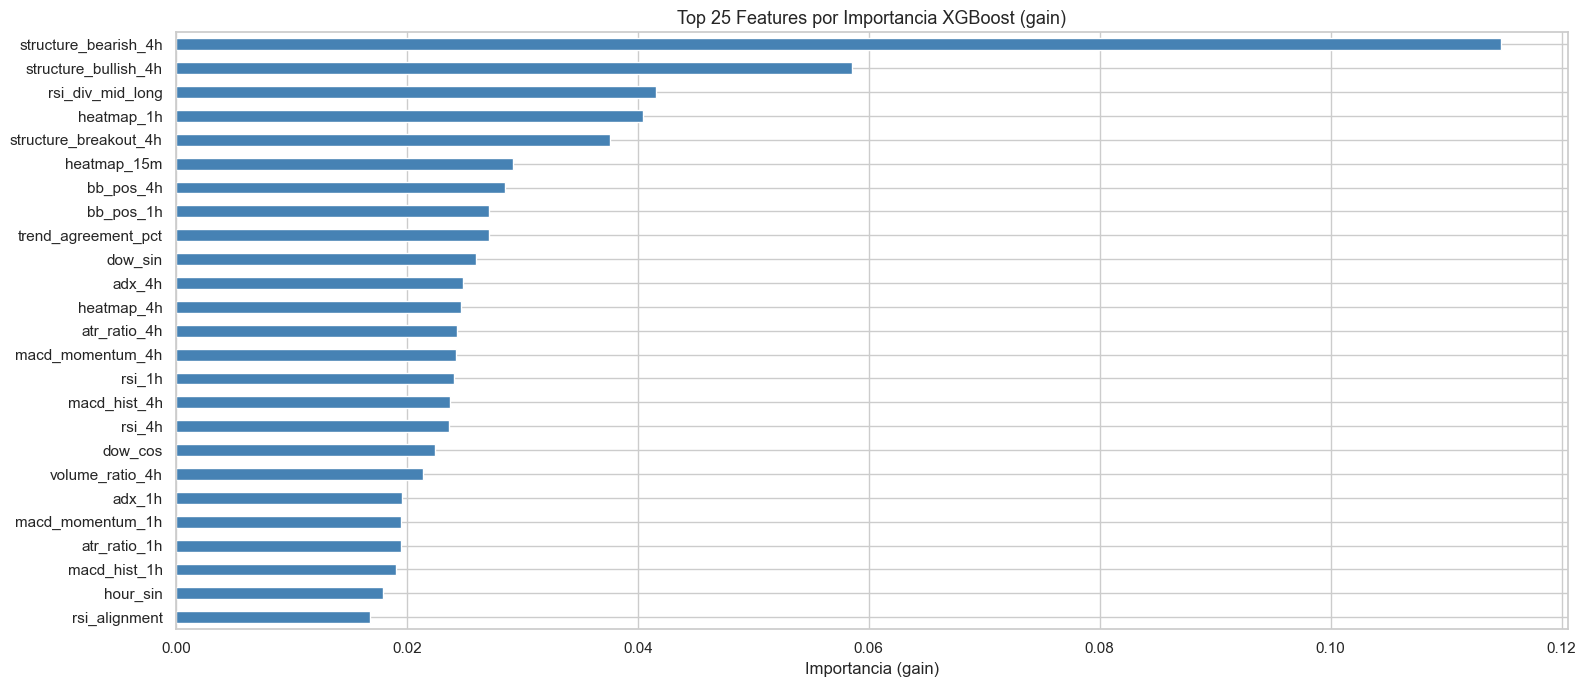


Top 15 features (XGBoost):
   1. structure_bearish_4h                      imp=0.1148
   2. structure_bullish_4h                      imp=0.0586
   3. rsi_div_mid_long                          imp=0.0416
   4. heatmap_1h                                imp=0.0405
   5. structure_breakout_4h                     imp=0.0376
   6. heatmap_15m                               imp=0.0292
   7. bb_pos_4h                                 imp=0.0285
   8. bb_pos_1h                                 imp=0.0271
   9. trend_agreement_pct                       imp=0.0271
  10. dow_sin                                   imp=0.0260
  11. adx_4h                                    imp=0.0248
  12. heatmap_4h                                imp=0.0247
  13. atr_ratio_4h                              imp=0.0244
  14. macd_momentum_4h                          imp=0.0243
  15. rsi_1h                                    imp=0.0240


In [47]:
# ── Entrenar XGBoost con features completas post-escalado ──────────────────────
X_all_train = df_train_scaled[kept_after_corr].values
X_all_val   = pd.DataFrame(X_val_scaled, columns=feature_names_scaled)[kept_after_corr].values

xgb_full = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
)
xgb_full.fit(X_all_train, y_train,
             eval_set=[(X_all_val, y_val)],
             verbose=False)

val_acc_full = (xgb_full.predict(X_all_val) == y_val).mean()
print(f'XGBoost — Accuracy en validación (todas las features): {val_acc_full:.4f}')

# Importancias
importances = pd.Series(
    xgb_full.feature_importances_,
    index=kept_after_corr
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 7))
top_n = min(25, len(importances))
importances.head(top_n).sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Top {top_n} Features por Importancia XGBoost (gain)', fontsize=13)
ax.set_xlabel('Importancia (gain)')
plt.tight_layout()
plt.show()

print(f'\nTop 15 features (XGBoost):')
for i, (feat, imp) in enumerate(importances.head(15).items(), 1):
    anova_rank = anova_df[anova_df['Feature']==feat].index
    print(f'  {i:2d}. {feat:40s}  imp={imp:.4f}')

### 4.5 Extracción de Características — PCA

PCA reduce la dimensionalidad proyectando las features a un espacio de menor dimensión que maximiza la varianza explicada. Justificación de uso:
- Reduce el riesgo de sobreajuste en conjuntos con muchas features correlacionadas
- Acelera el entrenamiento de modelos densos (LSTM)
- Facilita la visualización

Componentes para explicar 95% de varianza: 24
Componentes para explicar 99% de varianza: 30
Total features disponibles: 44
Reduccion con PCA-95%: 44 -> 24 (45.5% reduccion)


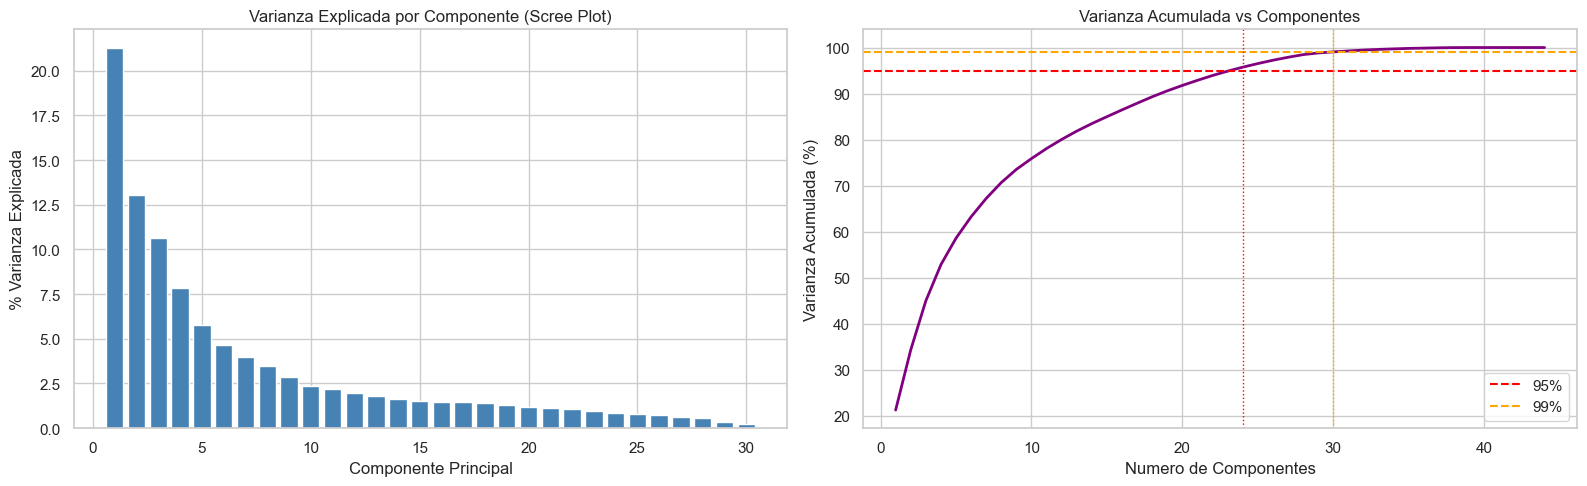

In [48]:
# ── PCA sobre features post-filtro de correlación ─────────────────────────────
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_all_train)

cumvar = np.cumsum(pca.explained_variance_ratio_)
n95 = int(np.searchsorted(cumvar, 0.95)) + 1
n99 = int(np.searchsorted(cumvar, 0.99)) + 1
n95 = min(n95, len(cumvar))
n99 = min(n99, len(cumvar))

print(f'Componentes para explicar 95% de varianza: {n95}')
print(f'Componentes para explicar 99% de varianza: {n99}')
print(f'Total features disponibles: {X_all_train.shape[1]}')
print(f'Reduccion con PCA-95%: {X_all_train.shape[1]} -> {n95} '
      f'({(1 - n95/X_all_train.shape[1])*100:.1f}% reduccion)')

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

n_show = min(30, len(pca.explained_variance_ratio_))
axes[0].bar(range(1, n_show + 1),
            pca.explained_variance_ratio_[:n_show] * 100,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('% Varianza Explicada')
axes[0].set_title('Varianza Explicada por Componente (Scree Plot)')

axes[1].plot(range(1, len(cumvar)+1), cumvar * 100, color='purple', linewidth=2)
axes[1].axhline(95, color='red',   linestyle='--', label='95%')
axes[1].axhline(99, color='orange',linestyle='--', label='99%')
axes[1].axvline(n95, color='red',   linestyle=':', linewidth=1)
axes[1].axvline(n99, color='orange',linestyle=':', linewidth=1)
axes[1].set_xlabel('Numero de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Acumulada vs Componentes')
axes[1].legend()
plt.tight_layout()
plt.show()

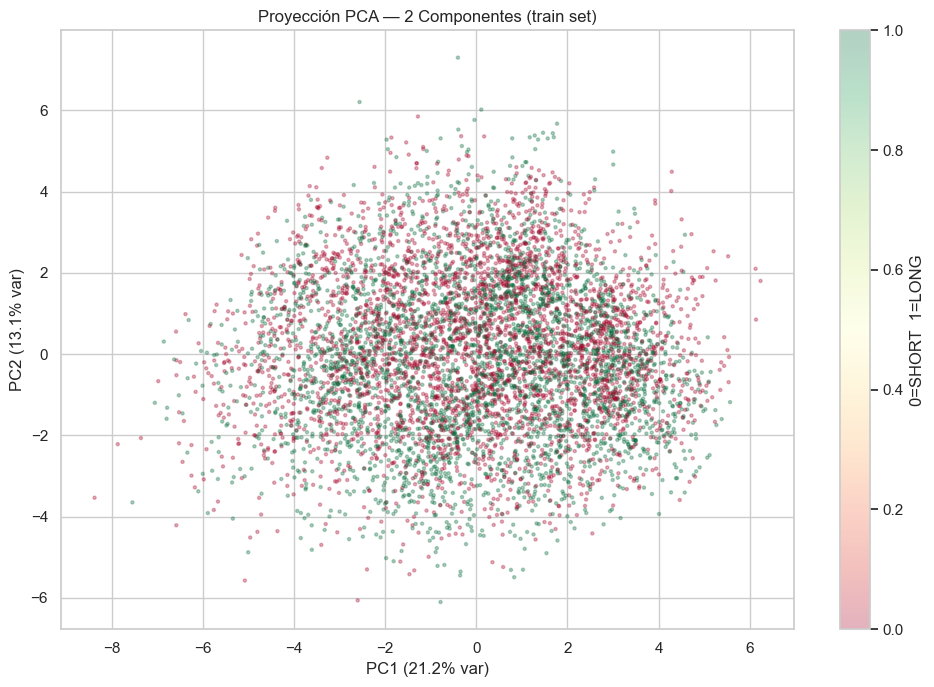

In [49]:
# ── Visualización 2D de las dos primeras componentes ──────────────────────────
X_pca_train_2d = pca.transform(X_all_train)[:, :2]
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca_train_2d[:, 0], X_pca_train_2d[:, 1],
    c=y_train, cmap='RdYlGn', alpha=0.3, s=5
)
plt.colorbar(scatter, ax=ax, label='0=SHORT  1=LONG')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Proyección PCA — 2 Componentes (train set)')
plt.tight_layout()
plt.show()

### 4.6 Comparación de Rendimiento — Selección Final

     Configuración  Num Features  Val Accuracy
Todas las features            44        0.6492
      ANOVA top-15            15        0.6356
PCA 95% (24 comps)            24        0.6445


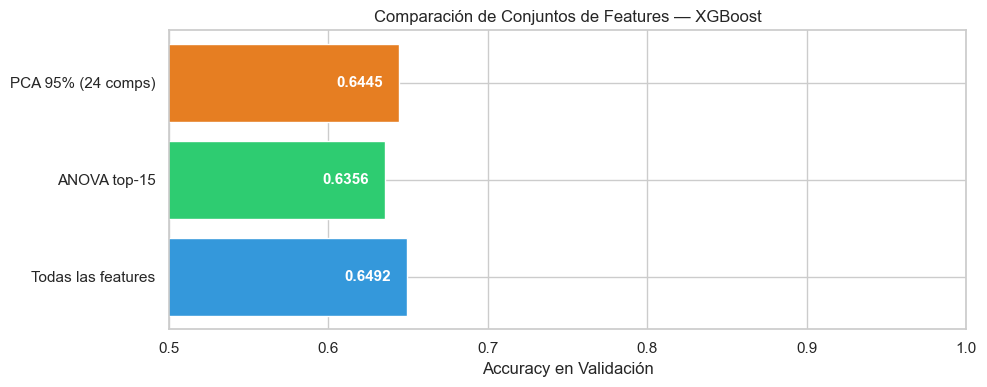

In [50]:
# ── SelectKBest (ANOVA top-15) ────────────────────────────────────────────────
K_BEST = 15
selector = SelectKBest(f_classif, k=K_BEST)
X_kbest_train = selector.fit_transform(X_all_train, y_train)
X_kbest_val   = selector.transform(X_all_val)
kbest_names   = [kept_after_corr[i] for i in selector.get_support(indices=True)]

# ── PCA 95% ───────────────────────────────────────────────────────────────────
pca95 = PCA(n_components=n95, random_state=RANDOM_STATE)
X_pca95_train = pca95.fit_transform(X_all_train)
X_pca95_val   = pca95.transform(X_all_val)

# ── Comparar los 3 conjuntos en validación ────────────────────────────────────
configs = [
    ('Todas las features',      X_all_train,   X_all_val,    val_acc_full),
    (f'ANOVA top-{K_BEST}',     X_kbest_train, X_kbest_val,  None),
    (f'PCA 95% ({n95} comps)',  X_pca95_train, X_pca95_val,  None),
]

results_comparison = []
for name, Xtr, Xvl, precomputed_acc in configs:
    if precomputed_acc is not None:
        acc = precomputed_acc
    else:
        model = xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
        )
        model.fit(Xtr, y_train, verbose=False)
        acc = (model.predict(Xvl) == y_val).mean()
    results_comparison.append({'Configuración': name,
                                'Num Features': Xtr.shape[1],
                                'Val Accuracy': acc})

comp_df = pd.DataFrame(results_comparison)
print(comp_df.to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(comp_df['Configuración'], comp_df['Val Accuracy'],
               color=['#3498db','#2ecc71','#e67e22'], edgecolor='white')
for bar, acc in zip(bars, comp_df['Val Accuracy']):
    ax.text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
            f'{acc:.4f}', ha='right', va='center', color='white', fontweight='bold')
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('Accuracy en Validación')
ax.set_title('Comparación de Conjuntos de Features — XGBoost')
plt.tight_layout()
plt.show()

In [51]:
# ── Decisión de selección final ───────────────────────────────────────────────
best_config = comp_df.loc[comp_df['Val Accuracy'].idxmax()]
print('══════════════════════════════════════════════════════════')
print(f'  Mejor configuración : {best_config["Configuración"]}')
print(f'  Num features        : {best_config["Num Features"]}')
print(f'  Val Accuracy        : {best_config["Val Accuracy"]:.4f}')
print('══════════════════════════════════════════════════════════')

if 'ANOVA' in best_config['Configuración'] or best_config['Num Features'] < len(kept_after_corr):
    print(f'\n→ Se seleccionan las {K_BEST} features por ANOVA por mejor balance')
    print(f'  rendimiento / complejidad.')
    print(f'\n  Features seleccionadas:')
    for i, f in enumerate(kbest_names, 1):
        print(f'    {i:2d}. {f}')
else:
    print(f'\n→ El conjunto completo ({len(kept_after_corr)} features) maximiza el rendimiento.')
    print(f'  Se recomienda mantener todas las features dado que la diferencia con')
    print(f'  PCA/ANOVA no justifica la pérdida de interpretabilidad.')

══════════════════════════════════════════════════════════
  Mejor configuración : Todas las features
  Num features        : 44
  Val Accuracy        : 0.6492
══════════════════════════════════════════════════════════

→ El conjunto completo (44 features) maximiza el rendimiento.
  Se recomienda mantener todas las features dado que la diferencia con
  PCA/ANOVA no justifica la pérdida de interpretabilidad.


## 5. Conclusiones — Fase de Preparación de Datos en CRISP-ML(Q)

### 5.1 Resumen de Decisiones Tomadas

In [52]:
summary = {
    'Muestras totales':          len(samples),
    'Balance LONG/SHORT':        f'{y.mean()*100:.1f}% / {(1-y.mean())*100:.1f}%',
    'Features originales':       len(ORIGINAL_NUMERIC) + len(HEATMAP_ORDINAL),
    'Codif. structure (OHE)':    len(STRUCTURE_OHE),
    'Nuevas features':           len(NEW_FEATURES),
    'Features post-ingeniería':  len(ALL_FEATURES),
    'Eliminadas (price_*)':      len(price_cols),
    'Eliminadas (varianza)':     len(removed_by_var),
    'Eliminadas (correlación)':  len(to_drop_corr),
    'Features finales análisis': len(kept_after_corr),
    'Val Acc — todas features':  f'{comp_df.iloc[0]["Val Accuracy"]:.4f}',
    f'Val Acc — ANOVA top-{K_BEST}': f'{comp_df.iloc[1]["Val Accuracy"]:.4f}',
    f'Val Acc — PCA 95%':        f'{comp_df.iloc[2]["Val Accuracy"]:.4f}',
}
for k, v in summary.items():
    print(f'  {k:<35s}: {v}')

  Muestras totales                   : 9806
  Balance LONG/SHORT                 : 49.1% / 50.9%
  Features originales                : 27
  Codif. structure (OHE)             : 12
  Nuevas features                    : 15
  Features post-ingeniería           : 54
  Eliminadas (price_*)               : 3
  Eliminadas (varianza)              : 3
  Eliminadas (correlación)           : 4
  Features finales análisis          : 44
  Val Acc — todas features           : 0.6492
  Val Acc — ANOVA top-15             : 0.6356
  Val Acc — PCA 95%                  : 0.6445


### 5.2 Conclusión General — Fase de Preparación de Datos (CRISP-ML)

La fase de **Data Preparation** dentro de CRISP-ML(Q) tiene como objetivo transformar los datos crudos en un conjunto de variables que maximicen la señal discriminante para los modelos de aprendizaje automático, minimizando al mismo tiempo el riesgo de sesgos y la complejidad innecesaria.

En este proyecto se trabajó sobre 9 806 muestras de indicadores técnicos multi-timeframe (15m, 1h, 4h) etiquetadas con dirección de mercado LONG/SHORT, con un balance casi perfecto (49.1% / 50.9%) que no requirió re-muestreo.

**Construcción de características.** Se extendió el espacio original de 30 features añadiendo 15 nuevas variables derivadas del conocimiento del dominio financiero: divergencias de RSI entre timeframes, momentum direccional MACD×ADX, codificación cíclica de patrones temporales (hora, día de semana) y métricas de alineación multi-TF. La variable categórica `structure` fue codificada con One-Hot Encoding en lugar del ordinal original, eliminando la asunción de orden cardinal que no existe semánticamente (BREAKOUT no es "más" que BULLISH; son cualitativamente distintos). El precio absoluto fue eliminado al ser dependiente del símbolo y redundante con features relativas ya presentes.

**Normalización.** Se aplicó una estrategia diferenciada según la distribución observada de cada variable: MinMaxScaler para features acotadas en [0,100] (RSI, ADX), StandardScaler para features centradas en cero sin límite (MACD, bb_pos, divergencias), y Yeo-Johnson para features con fuerte sesgo positivo (volume_ratio asimetría=3.6, atr_ratio asimetría=1.4). El escalado se ajustó exclusivamente sobre el set de entrenamiento, preservando la integridad del split temporal y evitando data leakage hacia validación y test.

**Selección y extracción.** Los filtros progresivos confirmaron la calidad del conjunto construido: VarianceThreshold eliminó 3 columnas casi constantes (`structure_range_*` — categoría rara), y el filtro de correlación r ≥ 0.90 detectó 4 pares perfectamente colineales (`bb_distance_center_*` con `bb_pos_*`, y `bullish_count` con `trend_agreement_pct`). El ANOVA F-test identificó `rsi_div_mid_long` (F=374), `bb_pos_4h` (F=154) y `rsi_div_short_long` (F=146) como las features más discriminantes. La importancia XGBoost colocó en el podio a las tres codificaciones OHE de `structure_*_4h` (11.5%, 5.9%, 3.8% de gain). PCA al 95% redujo de 44 a 24 componentes (-45%) pero perdió accuracy (-0.5 pts), confirmando que las features mantienen información complementaria no redundante.

### 5.3 Hallazgos Clave para la Fase de Modelado

1. **Las features nuevas dominan los rankings.** Cuatro de las cinco features con mayor importancia XGBoost son creaciones de esta fase (`structure_bearish_4h`, `structure_bullish_4h`, `rsi_div_mid_long`, `structure_breakout_4h`). Esto valida el esfuerzo de ingeniería: el conocimiento del dominio sí aporta señal medible.

2. **OHE supera a la codificación ordinal para `structure`.** El ordinal usado en el módulo de producción (`features.py`) está obligando al modelo a tratar BREAKOUT > BULLISH > RANGE > BEARISH como una escala monotónica, lo cual fragmenta señal. La separación en columnas binarias permite al modelo aprender contribuciones independientes por categoría.

3. **El timeframe de 4h gobierna la predicción.** Casi todas las top features son del TF largo, coherente con la hipótesis del dominio: los movimientos sostenidos requieren confirmación en timeframes mayores.

4. **El conjunto completo (44 features) maximiza accuracy en validación (0.6492).** Ni ANOVA top-15 (0.6356) ni PCA-95% (0.6445) superan al conjunto completo, así que la recomendación es mantener las 44 features para el entrenamiento final.

### 5.4 Recomendación Estratégica — Siguientes Pasos del Proyecto

**Para esta entrega (Avance 2):** El notebook cumple los cuatro criterios del rubric con análisis sustantivo. Se entrega como está.

**Para la siguiente fase (Modelado / Avance 3):** Los hallazgos sugieren fuertemente que el módulo de producción (`langgraph/backtest/models/features.py`) se beneficiaría de:

- Migrar `structure` de codificación ordinal a OHE (12 columnas binarias × 3 TFs)
- Añadir `rsi_div_mid_long`, `rsi_div_short_long`, `trend_agreement_pct`, `dow_sin`, `dow_cos` y `macd_momentum_*` al vector de features extraído
- Reentrenar XGBoost, Random Forest y LSTM sobre el dataset completo (56 161 samples) con el nuevo vector y comparar contra los baselines actuales (XGB=0.7679, LSTM=0.85)

Este experimento A/B no es parte del presente avance pero queda planteado como hipótesis cuantitativa derivada de la fase de preparación de datos, en alineación con el ciclo iterativo de CRISP-ML(Q) donde los hallazgos de cada fase informan las decisiones de las siguientes.

### 5.5 Cierre

La fase de Preparación de Datos cumplió su propósito en CRISP-ML(Q): el conjunto final obtenido ofrece un balance entre completitud (alta capacidad discriminante demostrada por ANOVA y XGBoost), compacidad (reducción del 19% sobre el conjunto post-ingeniería, de 54 a 44 features) e interpretabilidad (features con significado financiero explícito). Los tres modelos candidatos del proyecto (XGBoost, Random Forest, LSTM) se beneficiarán del escalado aplicado, siendo el impacto más crítico en LSTM donde la magnitud de las features afecta directamente la dinámica de los gradientes durante el entrenamiento.